# RQ1 – Comparer la "qualité" des PR entre humains et IA

**RQ1.** Comparer la qualité d'une PR entre un humain et une IA, en se basant sur :

1. **Grosseur de la PR**
   - additions totales
   - deletions totales
   - churn = additions + deletions
   - nombre de fichiers touchés

2. **Corrélation Additions ↔ Deletions**
   - permet  d’évaluer si la PR est stable ou intrusive

3. **Quantité de PR_reviews associées**
   - nombre de review comments
   - présence de changes_requested



In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


In [2]:
BASE = "hf://datasets/hao-li/AIDev"

# Core PR data
pr_df = pd.read_parquet(f"{BASE}/pull_request.parquet")
human_pr_df = pd.read_parquet(f"{BASE}/human_pull_request.parquet")
print("Overview")
print(pr_df.head())
print("Human PRs")
print(human_pr_df.head())

# Reviews
pr_reviews_df = pd.read_parquet(f"{BASE}/pr_reviews.parquet")
pr_review_comments_df = pd.read_parquet(f"{BASE}/pr_review_comments_v2.parquet")

# Commits & diffs
pr_commits_df = pd.read_parquet(f"{BASE}/pr_commits.parquet")
pr_commit_details_df = pd.read_parquet(f"{BASE}/pr_commit_details.parquet")

print("Load done")


Overview
           id  number                                              title                                               body        agent    user_id        user   state  \
0  3264933329    2911  Fix: Wait for all partitions in load_collectio...  ## Summary\n\nFixes an issue where `load_colle...  Claude_Code  108661493  weiliu1031  closed   
1  3265118634       2                   ファイルパス参照を相対パスに統一し、doc/からdocs/に統一  ## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...  Claude_Code   61827001  cm-kojimat  closed   
2  3265640341      30        Add build staleness detection for debug CLI  ## Summary\r\n\r\n  Implements comprehensive b...  Claude_Code       7475        MSch  closed   
3  3265709660     205  feat: add comprehensive README screenshots wit...  ## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...  Claude_Code      80381      sugyan  closed   
4  3265782173   17625        chore: remove HashedPostStateProvider trait  ## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...  Claude_Code

ArrowMemoryError: malloc of size 1521369088 failed

In [ ]:
# Agent PRs
agent_pr = pr_df.rename(columns={"id": "pr_id"}).copy()
agent_pr["source_type"] = "Agent"

# Human PRs
human_pr = human_pr_df.rename(columns={"id": "pr_id"}).copy()
human_pr["source_type"] = "Human"

combined_pr = pd.concat([agent_pr, human_pr], ignore_index=True)
combined_pr = combined_pr[["pr_id", "source_type"]]
combined_pr.head()


,pr_id,source_type
0,3264933329,Agent
1,3265118634,Agent
2,3265640341,Agent
3,3265709660,Agent
4,3265782173,Agent


In [ ]:
# Build mapping review → PR
print(pr_reviews_df.columns)
review_to_pr = pr_reviews_df[["id", "pr_id"]].rename(
    columns={"id": "pull_request_review_id", "pr_id": "pr_id"}
)

# Attach PR IDs to review comments
pr_review_comments_with_pr = pr_review_comments_df.merge(
    review_to_pr,
    on="pull_request_review_id",
    how="left"
)


Index(['id', 'pr_id', 'user', 'user_type', 'state', 'submitted_at', 'body'], dtype='object')


In [ ]:
ADD_COL = "additions"
DEL_COL = "deletions"
FILE_COL = "filename"
print(pr_commit_details_df.columns)
patch_metrics_df = (
    pr_commit_details_df
    .groupby("pr_id")
    .agg(
        total_additions=(ADD_COL, "sum"),
        total_deletions=(DEL_COL, "sum"),
        files_touched=(FILE_COL, "nunique")
    )
    .reset_index()
)

patch_metrics_df["churn"] = (
    patch_metrics_df["total_additions"] +
    patch_metrics_df["total_deletions"]
)

# corr add/del per PR
def corr_add_del(g):
    if len(g) < 2:
        return np.nan
    if g[ADD_COL].std() == 0 or g[DEL_COL].std() == 0:
        return np.nan
    return g[ADD_COL].corr(g[DEL_COL])

corr_series = (
    pr_commit_details_df
    .groupby("pr_id")
    .apply(corr_add_del)
    .rename("add_del_corr")
)

patch_metrics_df = patch_metrics_df.merge(corr_series, on="pr_id", how="left")

patch_metrics_df["new_code_fraction"] = (
    patch_metrics_df["total_additions"] /
    patch_metrics_df["churn"].replace({0: np.nan})
)

patch_metrics_df.head()


Index(['sha', 'pr_id', 'author', 'committer', 'message', 'commit_stats_total', 'commit_stats_additions', 'commit_stats_deletions', 'filename', 'status', 'additions', 'deletions',
       'changes', 'patch'],
      dtype='object')


c:\Users\mathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2845: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\mathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2704: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)


,pr_id,total_additions,total_deletions,files_touched,churn,add_del_corr,new_code_fraction
0,2756921963,848.0,344.0,15,1192.0,0.218797,0.711409
1,2757103560,517.0,262.0,16,779.0,0.593918,0.663671
2,2757124156,1.0,1.0,1,2.0,NaN,0.500000
3,2757125491,1.0,1.0,1,2.0,NaN,0.500000
4,2757179026,1633.0,169.0,15,1802.0,0.329740,0.906215


In [ ]:
# 5.1 Nombre de review comments
review_comments_count_df = (
    pr_review_comments_with_pr
    .groupby("pr_id")
    .size()
    .rename("n_review_comments")
    .reset_index()
)

# 5.2 CHANGES REQUESTED
review_state = pr_reviews_df.copy()
review_state["changes_requested"] = (
    review_state["state"]
    .astype(str)
    .str.contains("CHANGES_REQUESTED", case=False)
)

changes_requested_df = (
    review_state
    .groupby("pr_id")["changes_requested"]
    .max()
    .reset_index()
)


In [ ]:
# Nombre de commits dans la PR
commit_count_df = (
    pr_commits_df
    .groupby("pr_id")
    .size()
    .rename("n_commits")
    .reset_index()
)

revision_cycles_df = changes_requested_df.merge(
    commit_count_df, on="pr_id", how="left"
)

revision_cycles_df["revision_cycle_detected"] = (
    (revision_cycles_df["changes_requested"] == True) &
    (revision_cycles_df["n_commits"] > 1)
)

revision_cycles_df.head()


,pr_id,changes_requested,n_commits,revision_cycle_detected
0,2756921963,False,16.0,False
1,2758636941,True,15.0,True
2,2759620798,False,2.0,False
3,2760115428,True,8.0,True
4,2760243902,False,4.0,False


In [ ]:
metrics_df = (
    combined_pr
    .merge(patch_metrics_df, on="pr_id", how="left")
    .merge(review_comments_count_df, on="pr_id", how="left")
    .merge(revision_cycles_df, on="pr_id", how="left")
)

metrics_df.head()


,pr_id,source_type,total_additions,total_deletions,files_touched,churn,add_del_corr,new_code_fraction,n_review_comments,changes_requested,n_commits,revision_cycle_detected
0,3264933329,Agent,394.0,2.0,3.0,396.0,-0.999996,0.994949,NaN,NaN,NaN,NaN
1,3265118634,Agent,38.0,38.0,11.0,76.0,1.000000,0.500000,NaN,NaN,NaN,NaN
2,3265640341,Agent,298.0,109.0,5.0,407.0,-0.302710,0.732187,2.0,False,6.0,False
3,3265709660,Agent,288.0,12.0,15.0,300.0,-0.002694,0.960000,2.0,False,3.0,False
4,3265782173,Agent,53.0,168.0,21.0,221.0,-0.112212,0.239819,NaN,NaN,NaN,NaN


In [ ]:
cols_of_interest = [
    "total_additions", "total_deletions", "churn",
    "files_touched", "add_del_corr", "new_code_fraction",
    "n_review_comments", "n_commits", "revision_cycle_detected"
]

metrics_non_null = metrics_df.dropna(subset=cols_of_interest, how="all")

summary = (
    metrics_non_null
    .groupby("source_type")[cols_of_interest]
    .agg(["count", "mean", "median", "std"])
)

summary

total_additions                                  total_deletions                                   churn                                   files_touched             \
                      count        mean median           std           count        mean median           std  count         mean median           std         count       mean   
source_type                                                                                                                                                                       
Agent                 33580  1286.40137   72.0  12554.165001           33580  686.780405   10.0  10301.852716  33580  1973.181775   95.0  20589.139709         33580  17.150476   

                              add_del_corr                               new_code_fraction                           n_review_comments                            n_commits  \
            median        std        count      mean    median       std             count      mean median      std             count      mean median       std     count   
source_type                                                                                                                                                                   
Agent          3.0  55.088884        21881  0.177621  0.119544  0.644011             33078  0.749635    0.8  0.23491              4465  6.017469    3.0  8.324574      8134   

                                       revision_cycle_detected                             
                 mean median       std                   count      mean median       std  
source_type                                                                                
Agent        5.191296    3.0  5.631479                    8140  0.114865    0.0  0.318878

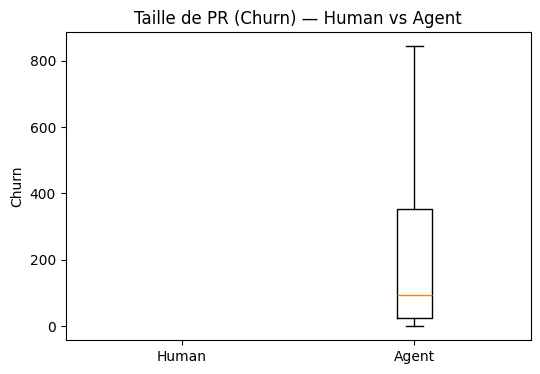

In [ ]:
# Churn Human vs Agent
fig, ax = plt.subplots(figsize=(6,4))

data = [
    metrics_df.loc[metrics_df["source_type"] == "Human", "churn"].dropna(),
    metrics_df.loc[metrics_df["source_type"] == "Agent", "churn"].dropna(),
]

ax.boxplot(data, labels=["Human", "Agent"], showfliers=False)
ax.set_title("Taille de PR (Churn) — Human vs Agent")
ax.set_ylabel("Churn")

plt.show()


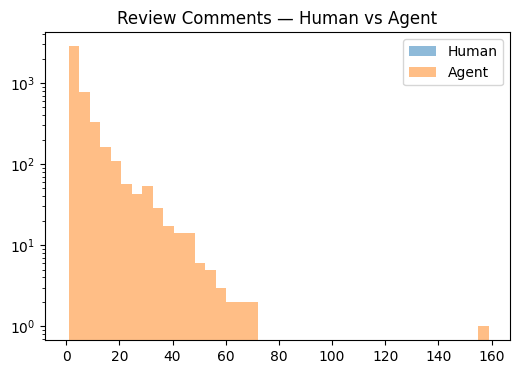

In [ ]:
# Review comments distribution
fig, ax = plt.subplots(figsize=(6,4))

for label in ["Human", "Agent"]:
    ax.hist(
        metrics_df.loc[metrics_df["source_type"] == label, "n_review_comments"].dropna(),
        bins=40, alpha=0.5, label=label
    )

ax.set_yscale("log")
ax.set_title("Review Comments — Human vs Agent")
plt.legend()
plt.show()


In [ ]:
def compare(metric):
    h = metrics_df.loc[metrics_df["source_type"]=="Human", metric].dropna()
    a = metrics_df.loc[metrics_df["source_type"]=="Agent", metric].dropna()
    u, p = stats.mannwhitneyu(h, a, alternative="two-sided")
    print(f"==== {metric} ====")
    print(f"Human mean={h.mean():.2f} — Agent mean={a.mean():.2f}")
    print(f"Mann-Whitney p={p:.3e}")

for c in cols:
    compare(c)


ValueError: `x` and `y` must be of nonzero size.